In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import h5py

from scipy.stats import binned_statistic

from pipeline.processing.fit_continuum import _powerlaw
from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark
from pipeline.processing.parameters import CIV_AIR, NV_AIR, LYA_AIR

FIT_PARAMS_PATH = "data/fit_params.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"
SPECTRA_PATH = "data/spectra.h5"

settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':6.0,
        'xtick.minor.size':4.0,
        'ytick.major.size':6.0,
        'ytick.minor.size':4.0,
        'legend.frameon':False,
    }

plt.rcParams.update(**settings)

In [84]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
fit_params = pd.read_csv(FIT_PARAMS_PATH,index_col=0,dtype={"targetid":"str"})

### basic composite

In [85]:
full = results[(results["z"]>2) & (results["z"]<3.4)]
core_erq = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]

In [5]:
lam_full = []
flux_full = []

In [6]:
for i, idx in enumerate(np.random.choice(full.index,20000)):
    with h5py.File(SPECTRA_PATH, "r") as f:
        data = f[f"{idx}"][()]

        lam = data[0,:]
        flux = data[1,:]

        cont_params = ast.literal_eval(fit_params.loc[idx,"continuum_fit_lya_nv"])["fit_params"]

        cont_flux = _powerlaw(lam/1290,**cont_params)

        lam_full.extend(lam)
        flux_full.extend(flux/cont_flux)

/tmp/ipykernel_497/4044092467.py:13: RuntimeWarning: divide by zero encountered in divide
  flux_full.extend(flux/cont_flux)


In [86]:
lam_core_erq = []
flux_core_erq = []

In [87]:
for idx in core_erq.index:
    with h5py.File(SPECTRA_PATH, "r") as f:
        data = f[f"{idx}"][()]

        lam = data[0,:]
        flux = data[1,:]

        cont_params = ast.literal_eval(fit_params.loc[idx,"continuum_fit_lya_nv"])["fit_params"]

        cont_flux = _powerlaw(lam/1290,**cont_params)

        lam_core_erq.extend(lam)
        flux_core_erq.extend(flux/cont_flux)

/tmp/ipykernel_9773/2725202399.py:13: RuntimeWarning: divide by zero encountered in divide
  flux_core_erq.extend(flux/cont_flux)


In [88]:
# median_full = binned_statistic(x=lam_full,values=flux_full,statistic="median",bins=(818))
median_core_erq = binned_statistic(x=lam_core_erq,values=flux_core_erq,statistic="median",bins=(818))

In [ ]:
# with open("data/local/median_full_backup.txt","w") as f:
#     f.write(str(median_full))

In [ ]:
# with open("data/local/median_full_backup.txt","r") as f:
#     median_full = f.read()

In [91]:
median_full_0 = [0.8346204 , 0.84160062, 0.84152711, 0.84213551, 0.84126973,
       0.84333426, 0.8426735 , 0.84812982, 0.84506148, 0.85111284,
       0.85597308, 0.85800611, 0.86220409, 0.86362566, 0.87199277,
       0.87356452, 0.87754608, 0.88958966, 0.89497895, 0.90638759,
       0.9109868 , 0.92181408, 0.92790004, 0.9371319 , 0.94694062,
       0.96325017, 0.97546027, 0.99155918, 1.00749222, 1.01727232,
       1.02305328, 1.04106568, 1.04049055, 1.04453454, 1.05362849,
       1.05650999, 1.05452185, 1.06300802, 1.06463544, 1.07704602,
       1.0818853 , 1.09041703, 1.10963986, 1.12419175, 1.13884586,
       1.16258473, 1.18716184, 1.19963197, 1.22213008, 1.24995817,
       1.27873198, 1.31159732, 1.33546587, 1.37058287, 1.40660331,
       1.43047548, 1.45977446, 1.50235919, 1.53473301, 1.57874566,
       1.61592811, 1.67310523, 1.72328914, 1.76698981, 1.81803554,
       1.88200488, 1.94767571, 2.03865396, 2.13042617, 2.22739747,
       2.34183531, 2.43656411, 2.55675369, 2.68539924, 2.82924505,
       2.93256204, 3.16006805, 3.39169699, 3.63528024, 3.97944051,
       4.07243441, 5.29046267, 5.64144793, 5.16206538, 4.65216202,
       4.2507414 , 3.91010123, 3.64212122, 3.40851757, 3.20594602,
       3.03872785, 2.89209645, 2.75991538, 2.64480342, 2.55273342,
       2.47641647, 2.41027288, 2.35211566, 2.30977392, 2.26930556,
       2.24739303, 2.22614852, 2.21605992, 2.2128176 , 2.21177099,
       2.22616107, 2.23785293, 2.26112028, 2.27806498, 2.29943942,
       2.33300537, 2.31145154, 2.28023957, 2.25225764, 2.20946136,
       2.16884527, 2.08089693, 1.97764666, 1.89538342, 1.82386039,
       1.76413605, 1.70952225, 1.66845803, 1.62546896, 1.59480997,
       1.56264151, 1.53653599, 1.50612083, 1.48453342, 1.46159472,
       1.44292449, 1.42335465, 1.41477175, 1.39655284, 1.38094893,
       1.37100726, 1.35976565, 1.34792265, 1.3406847 , 1.33145238,
       1.32289439, 1.30769223, 1.29891083, 1.28423327, 1.26845897,
       1.25097437, 1.23316697, 1.22108172, 1.20264035, 1.1884857 ,
       1.17572931, 1.16255355, 1.1486699 , 1.13696484, 1.12473157,
       1.11558618, 1.10528759, 1.10111914, 1.09362576, 1.08677651,
       1.08256035, 1.07388123, 1.07398109, 1.06761474, 1.06490968,
       1.06489165, 1.06144555, 1.05683871, 1.05826962, 1.05852031,
       1.05720535, 1.05861852, 1.05930522, 1.05974748, 1.0638944 ,
       1.06635973, 1.07156905, 1.07348772, 1.07912817, 1.08658986,
       1.08722023, 1.10057256, 1.10392806, 1.11016797, 1.11876784,
       1.12438279, 1.13509263, 1.14377606, 1.15772813, 1.1664604 ,
       1.17598991, 1.17998458, 1.1856645 , 1.18442235, 1.17949169,
       1.17583064, 1.16741439, 1.15762669, 1.1472248 , 1.13454118,
       1.11934958, 1.10756554, 1.09490604, 1.08349273, 1.07182541,
       1.05908711, 1.05489981, 1.04538214, 1.04138712, 1.03737831,
       1.03457495, 1.02779376, 1.02738628, 1.02851808, 1.0258112 ,
       1.02501149, 1.02808089, 1.03000979, 1.03019605, 1.03543318,
       1.03771936, 1.04092821, 1.04828733, 1.05183483, 1.06334992,
       1.07035258, 1.08098791, 1.08730335, 1.09828628, 1.10187782,
       1.104643  , 1.10217129, 1.09700203, 1.0915914 , 1.08541624,
       1.07698594, 1.06788757, 1.06760497, 1.0609641 , 1.05319727,
       1.05220026, 1.04782925, 1.04471544, 1.04241542, 1.03920291,
       1.03688048, 1.0314975 , 1.02657341, 1.02557548, 1.02463285,
       1.02275028, 1.02116316, 1.02042669, 1.02212895, 1.01937129,
       1.02357509, 1.02306455, 1.02600155, 1.02650767, 1.02815102,
       1.03067895, 1.03080735, 1.03172482, 1.03703723, 1.03951525,
       1.03768564, 1.04172911, 1.04339145, 1.04502474, 1.04317106,
       1.04580279, 1.04846825, 1.04562275, 1.04795238, 1.04882718,
       1.05389937, 1.05376663, 1.05641201, 1.05930945, 1.06462932,
       1.06941869, 1.07367543, 1.07969098, 1.08329419, 1.09244892,
       1.09633087, 1.10268118, 1.10856638, 1.12105414, 1.1277503 ,
       1.13963093, 1.15270142, 1.1656164 , 1.17828686, 1.19261249,
       1.21140334, 1.22513282, 1.24253086, 1.25968305, 1.2802852 ,
       1.2982563 , 1.31115243, 1.32623621, 1.33086831, 1.33210599,
       1.33269503, 1.33342864, 1.34077616, 1.3439065 , 1.35300825,
       1.35964703, 1.36258884, 1.35944453, 1.35648123, 1.34766431,
       1.32586126, 1.30951379, 1.28397278, 1.25943923, 1.24405754,
       1.22144884, 1.20206181, 1.19026093, 1.17317012, 1.16285624,
       1.15012097, 1.13705157, 1.12896578, 1.11918032, 1.10927598,
       1.09911392, 1.09320119, 1.08573952, 1.08153595, 1.07480675,
       1.07004603, 1.06250781, 1.06036549, 1.05325279, 1.04884448,
       1.04738638, 1.03993862, 1.03727056, 1.03308918, 1.03209454,
       1.02674098, 1.02398676, 1.02012741, 1.01804947, 1.01389888,
       1.01305162, 1.00816618, 1.00825081, 1.00504378, 1.0027281 ,
       1.00128815, 0.99651264, 0.99702665, 0.9943425 , 0.99288748,
       0.99332067, 0.98923237, 0.98721886, 0.98587008, 0.98431413,
       0.98523521, 0.9803086 , 0.98081742, 0.98114655, 0.97861821,
       0.97879689, 0.97887163, 0.97738364, 0.97928205, 0.97901525,
       0.9804301 , 0.98030833, 0.98160587, 0.98086383, 0.98426963,
       0.98203131, 0.98374329, 0.98021709, 0.98084972, 0.98282122,
       0.98427971, 0.97941741, 0.98432128, 0.98294895, 0.98594981,
       0.98335916, 0.98460349, 0.98631105, 0.98744988, 0.98930288,
       0.99032764, 0.99116458, 0.99645375, 0.99678146, 0.99908932,
       0.99876542, 1.00203873, 1.00591525, 1.00878749, 1.01087084,
       1.01510463, 1.01746299, 1.02408156, 1.02961704, 1.03191351,
       1.03726797, 1.04438561, 1.0512336 , 1.05605985, 1.05943049,
       1.06121729, 1.06178257, 1.06334748, 1.06108422, 1.06155243,
       1.05571545, 1.05507586, 1.05506165, 1.05377228, 1.05841385,
       1.05768359, 1.06148739, 1.06148121, 1.06524465, 1.06929089,
       1.07051629, 1.07136298, 1.0769962 , 1.0787357 , 1.08075287,
       1.08331772, 1.08794119, 1.08954464, 1.0937243 , 1.09570313,
       1.10170712, 1.10352803, 1.10641593, 1.11546733, 1.12090567,
       1.1243572 , 1.13070775, 1.13610119, 1.14561848, 1.15203067,
       1.16099693, 1.1725262 , 1.17974734, 1.18921773, 1.19963988,
       1.21183663, 1.22466561, 1.23654   , 1.2541496 , 1.26904445,
       1.28615527, 1.30277164, 1.32194613, 1.34233334, 1.36594419,
       1.38430484, 1.40660314, 1.43211002, 1.45578665, 1.47942686,
       1.50932598, 1.53485428, 1.56583392, 1.59731671, 1.62906771,
       1.66262034, 1.69691134, 1.73173563, 1.77053253, 1.81323918,
       1.8561125 , 1.90353292, 1.95416715, 2.0158064 , 2.07498203,
       2.13615108, 2.20211839, 2.2819468 , 2.36700777, 2.44697901,
       2.55078844, 2.64779973, 2.70653512, 2.8455283 , 2.9174858 ,
       2.87164693, 2.84285571, 2.78492493, 2.64055805, 2.49607155,
       2.35483878, 2.23677163, 2.13910362, 2.0498358 , 1.98073578,
       1.91491336, 1.85634519, 1.80146494, 1.75217947, 1.71127705,
       1.66959436, 1.62981635, 1.5970169 , 1.56478993, 1.53431254,
       1.50669952, 1.48264492, 1.45924047, 1.43794494, 1.42170777,
       1.39939242, 1.38278968, 1.36735828, 1.3498411 , 1.33932778,
       1.32476495, 1.30948069, 1.29768017, 1.28610133, 1.27408055,
       1.26245868, 1.25348159, 1.24227768, 1.23505304, 1.22449782,
       1.22034234, 1.21039559, 1.2034012 , 1.19651506, 1.1908942 ,
       1.18857554, 1.17967831, 1.17707079, 1.17039246, 1.1684284 ,
       1.16455642, 1.16160352, 1.1569202 , 1.15419939, 1.15101011,
       1.14910744, 1.14692259, 1.14541601, 1.14487935, 1.14569349,
       1.14439383, 1.14526769, 1.14378897, 1.14338961, 1.1424011 ,
       1.141542  , 1.13734631, 1.13746739, 1.13613018, 1.13185597,
       1.13308485, 1.13304064, 1.13328115, 1.13284891, 1.13364864,
       1.13094231, 1.12974157, 1.1299807 , 1.13006977, 1.1312104 ,
       1.13259359, 1.12961199, 1.13325451, 1.13409   , 1.13538654,
       1.13522425, 1.13726355, 1.13970454, 1.13817028, 1.1382286 ,
       1.1365679 , 1.14267032, 1.14169674, 1.14517495, 1.14597964,
       1.15012605, 1.15244518, 1.15423304, 1.15960292, 1.1633699 ,
       1.16723411, 1.17253308, 1.17990893, 1.18535803, 1.19359594,
       1.20182047, 1.21001355, 1.22243102, 1.22977632, 1.24337744,
       1.25250615, 1.25973079, 1.2588491 , 1.24685897, 1.22289548,
       1.19951978, 1.18324529, 1.16511145, 1.15580868, 1.14794523,
       1.14424459, 1.14103663, 1.1347653 , 1.13263149, 1.12870855,
       1.12728529, 1.12349697, 1.12517586, 1.12405498, 1.12587465,
       1.12544899, 1.12759096, 1.12811006, 1.13224045, 1.13565077,
       1.13834228, 1.14323867, 1.14456926, 1.14646907, 1.14744845,
       1.14936355, 1.14748177, 1.14889814, 1.14902038, 1.14738974,
       1.14370398, 1.13231361, 1.12486775, 1.11396653, 1.10540282,
       1.10046876, 1.09267728, 1.08328058, 1.07892854, 1.07066193,
       1.06626434, 1.05689688, 1.05203222, 1.0450636 , 1.04074038,
       1.03650015, 1.02840168, 1.02296138, 1.02096155, 1.01499624,
       1.0109998 , 1.00732638, 1.00459505, 1.00183647, 0.99838829,
       0.99503031, 0.9935097 , 0.99048553, 0.98895375, 0.98976237,
       0.98645606, 0.98492511, 0.98477017, 0.98287316, 0.98403803,
       0.98375846, 0.98123269, 0.98191928, 0.98218169, 0.98050262,
       0.98020289, 0.98156762, 0.98268824, 0.98165452, 0.98226814,
       0.98284897, 0.98321057, 0.98611958, 0.98474281, 0.98672443,
       0.98933843, 0.99169379, 0.99088498, 0.99397553, 0.99387623,
       0.99678849, 0.99800883, 0.99954141, 1.00026396, 1.00232645,
       1.00238957, 1.00762082, 1.00622853, 1.00781764, 1.00678758,
       1.00939288, 1.01090713, 1.00782284, 1.00786448, 1.0105116 ,
       1.00660971, 1.01050166, 1.0091066 , 1.00942911, 1.01174717,
       1.01260638, 1.00982918, 1.01028628, 1.01291462, 1.01111574,
       1.01068222, 1.01081019, 1.01118001, 1.01027051, 1.01293273,
       1.01020109, 1.0136479 , 1.01388584, 1.01712266, 1.01804548,
       1.02060407, 1.0247305 , 1.02650551, 1.03236666, 1.03596776,
       1.03900875, 1.04353668, 1.04896287, 1.04851715, 1.05415561,
       1.05845688, 1.05866378, 1.05921959, 1.06021346, 1.05531458,
       1.05401792, 1.05046912, 1.04629293, 1.04263422, 1.03761434,
       1.03147894, 1.02866466, 1.02668452, 1.02021058, 1.01617766,
       1.01614156, 1.01015927, 1.00573284, 1.00702753, 1.00119571,
       0.99948552, 0.99846483, 0.99402805, 0.99677961, 0.99084609,
       0.99100402, 0.98889763, 0.99104268, 0.98728508, 0.98672099,
       0.98715564, 0.98578559, 0.98728251, 0.98415209, 0.98405539,
       0.98372479, 0.98500433, 0.98573286, 0.98398849, 0.98408005,
       0.98802735, 0.98917857, 0.99010791, 0.99148419, 0.99346197,
       0.99551725, 1.00065769, 1.00005718, 1.00084562, 1.00217363,
       1.00045856, 0.99868106, 0.9978788 , 0.99449735, 0.99350889,
       0.98972514, 0.98762147, 0.98529029, 0.98455556, 0.9850989 ,
       0.98149126, 0.9784918 , 0.98112146, 0.97619043, 0.97635332,
       0.97671239, 0.97472085, 0.97790963, 0.97889344, 0.9787865 ,
       0.97772187, 0.98166017, 0.98243874, 0.98270884, 0.98325039,
       0.98348375, 0.98399124, 0.98267776]

median_full_1 = [1150.00000469, 1150.80685065, 1151.6136966 , 1152.42054256,
       1153.22738852, 1154.03423448, 1154.84108044, 1155.64792639,
       1156.45477235, 1157.26161831, 1158.06846427, 1158.87531022,
       1159.68215618, 1160.48900214, 1161.2958481 , 1162.10269406,
       1162.90954001, 1163.71638597, 1164.52323193, 1165.33007789,
       1166.13692384, 1166.9437698 , 1167.75061576, 1168.55746172,
       1169.36430768, 1170.17115363, 1170.97799959, 1171.78484555,
       1172.59169151, 1173.39853746, 1174.20538342, 1175.01222938,
       1175.81907534, 1176.6259213 , 1177.43276725, 1178.23961321,
       1179.04645917, 1179.85330513, 1180.66015108, 1181.46699704,
       1182.273843  , 1183.08068896, 1183.88753492, 1184.69438087,
       1185.50122683, 1186.30807279, 1187.11491875, 1187.9217647 ,
       1188.72861066, 1189.53545662, 1190.34230258, 1191.14914854,
       1191.95599449, 1192.76284045, 1193.56968641, 1194.37653237,
       1195.18337832, 1195.99022428, 1196.79707024, 1197.6039162 ,
       1198.41076216, 1199.21760811, 1200.02445407, 1200.83130003,
       1201.63814599, 1202.44499194, 1203.2518379 , 1204.05868386,
       1204.86552982, 1205.67237578, 1206.47922173, 1207.28606769,
       1208.09291365, 1208.89975961, 1209.70660556, 1210.51345152,
       1211.32029748, 1212.12714344, 1212.9339894 , 1213.74083535,
       1214.54768131, 1215.35452727, 1216.16137323, 1216.96821918,
       1217.77506514, 1218.5819111 , 1219.38875706, 1220.19560302,
       1221.00244897, 1221.80929493, 1222.61614089, 1223.42298685,
       1224.2298328 , 1225.03667876, 1225.84352472, 1226.65037068,
       1227.45721664, 1228.26406259, 1229.07090855, 1229.87775451,
       1230.68460047, 1231.49144642, 1232.29829238, 1233.10513834,
       1233.9119843 , 1234.71883026, 1235.52567621, 1236.33252217,
       1237.13936813, 1237.94621409, 1238.75306004, 1239.559906  ,
       1240.36675196, 1241.17359792, 1241.98044388, 1242.78728983,
       1243.59413579, 1244.40098175, 1245.20782771, 1246.01467366,
       1246.82151962, 1247.62836558, 1248.43521154, 1249.2420575 ,
       1250.04890345, 1250.85574941, 1251.66259537, 1252.46944133,
       1253.27628728, 1254.08313324, 1254.8899792 , 1255.69682516,
       1256.50367112, 1257.31051707, 1258.11736303, 1258.92420899,
       1259.73105495, 1260.5379009 , 1261.34474686, 1262.15159282,
       1262.95843878, 1263.76528474, 1264.57213069, 1265.37897665,
       1266.18582261, 1266.99266857, 1267.79951452, 1268.60636048,
       1269.41320644, 1270.2200524 , 1271.02689836, 1271.83374431,
       1272.64059027, 1273.44743623, 1274.25428219, 1275.06112814,
       1275.8679741 , 1276.67482006, 1277.48166602, 1278.28851198,
       1279.09535793, 1279.90220389, 1280.70904985, 1281.51589581,
       1282.32274176, 1283.12958772, 1283.93643368, 1284.74327964,
       1285.5501256 , 1286.35697155, 1287.16381751, 1287.97066347,
       1288.77750943, 1289.58435538, 1290.39120134, 1291.1980473 ,
       1292.00489326, 1292.81173922, 1293.61858517, 1294.42543113,
       1295.23227709, 1296.03912305, 1296.845969  , 1297.65281496,
       1298.45966092, 1299.26650688, 1300.07335284, 1300.88019879,
       1301.68704475, 1302.49389071, 1303.30073667, 1304.10758262,
       1304.91442858, 1305.72127454, 1306.5281205 , 1307.33496646,
       1308.14181241, 1308.94865837, 1309.75550433, 1310.56235029,
       1311.36919624, 1312.1760422 , 1312.98288816, 1313.78973412,
       1314.59658008, 1315.40342603, 1316.21027199, 1317.01711795,
       1317.82396391, 1318.63080986, 1319.43765582, 1320.24450178,
       1321.05134774, 1321.8581937 , 1322.66503965, 1323.47188561,
       1324.27873157, 1325.08557753, 1325.89242348, 1326.69926944,
       1327.5061154 , 1328.31296136, 1329.11980732, 1329.92665327,
       1330.73349923, 1331.54034519, 1332.34719115, 1333.1540371 ,
       1333.96088306, 1334.76772902, 1335.57457498, 1336.38142094,
       1337.18826689, 1337.99511285, 1338.80195881, 1339.60880477,
       1340.41565072, 1341.22249668, 1342.02934264, 1342.8361886 ,
       1343.64303456, 1344.44988051, 1345.25672647, 1346.06357243,
       1346.87041839, 1347.67726434, 1348.4841103 , 1349.29095626,
       1350.09780222, 1350.90464818, 1351.71149413, 1352.51834009,
       1353.32518605, 1354.13203201, 1354.93887796, 1355.74572392,
       1356.55256988, 1357.35941584, 1358.1662618 , 1358.97310775,
       1359.77995371, 1360.58679967, 1361.39364563, 1362.20049158,
       1363.00733754, 1363.8141835 , 1364.62102946, 1365.42787542,
       1366.23472137, 1367.04156733, 1367.84841329, 1368.65525925,
       1369.4621052 , 1370.26895116, 1371.07579712, 1371.88264308,
       1372.68948904, 1373.49633499, 1374.30318095, 1375.11002691,
       1375.91687287, 1376.72371882, 1377.53056478, 1378.33741074,
       1379.1442567 , 1379.95110266, 1380.75794861, 1381.56479457,
       1382.37164053, 1383.17848649, 1383.98533244, 1384.7921784 ,
       1385.59902436, 1386.40587032, 1387.21271628, 1388.01956223,
       1388.82640819, 1389.63325415, 1390.44010011, 1391.24694606,
       1392.05379202, 1392.86063798, 1393.66748394, 1394.4743299 ,
       1395.28117585, 1396.08802181, 1396.89486777, 1397.70171373,
       1398.50855968, 1399.31540564, 1400.1222516 , 1400.92909756,
       1401.73594352, 1402.54278947, 1403.34963543, 1404.15648139,
       1404.96332735, 1405.7701733 , 1406.57701926, 1407.38386522,
       1408.19071118, 1408.99755713, 1409.80440309, 1410.61124905,
       1411.41809501, 1412.22494097, 1413.03178692, 1413.83863288,
       1414.64547884, 1415.4523248 , 1416.25917075, 1417.06601671,
       1417.87286267, 1418.67970863, 1419.48655459, 1420.29340054,
       1421.1002465 , 1421.90709246, 1422.71393842, 1423.52078437,
       1424.32763033, 1425.13447629, 1425.94132225, 1426.74816821,
       1427.55501416, 1428.36186012, 1429.16870608, 1429.97555204,
       1430.78239799, 1431.58924395, 1432.39608991, 1433.20293587,
       1434.00978183, 1434.81662778, 1435.62347374, 1436.4303197 ,
       1437.23716566, 1438.04401161, 1438.85085757, 1439.65770353,
       1440.46454949, 1441.27139545, 1442.0782414 , 1442.88508736,
       1443.69193332, 1444.49877928, 1445.30562523, 1446.11247119,
       1446.91931715, 1447.72616311, 1448.53300907, 1449.33985502,
       1450.14670098, 1450.95354694, 1451.7603929 , 1452.56723885,
       1453.37408481, 1454.18093077, 1454.98777673, 1455.79462269,
       1456.60146864, 1457.4083146 , 1458.21516056, 1459.02200652,
       1459.82885247, 1460.63569843, 1461.44254439, 1462.24939035,
       1463.05623631, 1463.86308226, 1464.66992822, 1465.47677418,
       1466.28362014, 1467.09046609, 1467.89731205, 1468.70415801,
       1469.51100397, 1470.31784993, 1471.12469588, 1471.93154184,
       1472.7383878 , 1473.54523376, 1474.35207971, 1475.15892567,
       1475.96577163, 1476.77261759, 1477.57946355, 1478.3863095 ,
       1479.19315546, 1480.00000142, 1480.80684738, 1481.61369333,
       1482.42053929, 1483.22738525, 1484.03423121, 1484.84107717,
       1485.64792312, 1486.45476908, 1487.26161504, 1488.068461  ,
       1488.87530695, 1489.68215291, 1490.48899887, 1491.29584483,
       1492.10269079, 1492.90953674, 1493.7163827 , 1494.52322866,
       1495.33007462, 1496.13692057, 1496.94376653, 1497.75061249,
       1498.55745845, 1499.36430441, 1500.17115036, 1500.97799632,
       1501.78484228, 1502.59168824, 1503.39853419, 1504.20538015,
       1505.01222611, 1505.81907207, 1506.62591803, 1507.43276398,
       1508.23960994, 1509.0464559 , 1509.85330186, 1510.66014781,
       1511.46699377, 1512.27383973, 1513.08068569, 1513.88753165,
       1514.6943776 , 1515.50122356, 1516.30806952, 1517.11491548,
       1517.92176143, 1518.72860739, 1519.53545335, 1520.34229931,
       1521.14914527, 1521.95599122, 1522.76283718, 1523.56968314,
       1524.3765291 , 1525.18337505, 1525.99022101, 1526.79706697,
       1527.60391293, 1528.41075889, 1529.21760484, 1530.0244508 ,
       1530.83129676, 1531.63814272, 1532.44498867, 1533.25183463,
       1534.05868059, 1534.86552655, 1535.67237251, 1536.47921846,
       1537.28606442, 1538.09291038, 1538.89975634, 1539.70660229,
       1540.51344825, 1541.32029421, 1542.12714017, 1542.93398613,
       1543.74083208, 1544.54767804, 1545.354524  , 1546.16136996,
       1546.96821591, 1547.77506187, 1548.58190783, 1549.38875379,
       1550.19559975, 1551.0024457 , 1551.80929166, 1552.61613762,
       1553.42298358, 1554.22982953, 1555.03667549, 1555.84352145,
       1556.65036741, 1557.45721337, 1558.26405932, 1559.07090528,
       1559.87775124, 1560.6845972 , 1561.49144315, 1562.29828911,
       1563.10513507, 1563.91198103, 1564.71882699, 1565.52567294,
       1566.3325189 , 1567.13936486, 1567.94621082, 1568.75305677,
       1569.55990273, 1570.36674869, 1571.17359465, 1571.98044061,
       1572.78728656, 1573.59413252, 1574.40097848, 1575.20782444,
       1576.01467039, 1576.82151635, 1577.62836231, 1578.43520827,
       1579.24205423, 1580.04890018, 1580.85574614, 1581.6625921 ,
       1582.46943806, 1583.27628401, 1584.08312997, 1584.88997593,
       1585.69682189, 1586.50366785, 1587.3105138 , 1588.11735976,
       1588.92420572, 1589.73105168, 1590.53789763, 1591.34474359,
       1592.15158955, 1592.95843551, 1593.76528147, 1594.57212742,
       1595.37897338, 1596.18581934, 1596.9926653 , 1597.79951125,
       1598.60635721, 1599.41320317, 1600.22004913, 1601.02689509,
       1601.83374104, 1602.640587  , 1603.44743296, 1604.25427892,
       1605.06112487, 1605.86797083, 1606.67481679, 1607.48166275,
       1608.28850871, 1609.09535466, 1609.90220062, 1610.70904658,
       1611.51589254, 1612.32273849, 1613.12958445, 1613.93643041,
       1614.74327637, 1615.55012233, 1616.35696828, 1617.16381424,
       1617.9706602 , 1618.77750616, 1619.58435211, 1620.39119807,
       1621.19804403, 1622.00488999, 1622.81173595, 1623.6185819 ,
       1624.42542786, 1625.23227382, 1626.03911978, 1626.84596573,
       1627.65281169, 1628.45965765, 1629.26650361, 1630.07334957,
       1630.88019552, 1631.68704148, 1632.49388744, 1633.3007334 ,
       1634.10757935, 1634.91442531, 1635.72127127, 1636.52811723,
       1637.33496319, 1638.14180914, 1638.9486551 , 1639.75550106,
       1640.56234702, 1641.36919297, 1642.17603893, 1642.98288489,
       1643.78973085, 1644.59657681, 1645.40342276, 1646.21026872,
       1647.01711468, 1647.82396064, 1648.63080659, 1649.43765255,
       1650.24449851, 1651.05134447, 1651.85819043, 1652.66503638,
       1653.47188234, 1654.2787283 , 1655.08557426, 1655.89242021,
       1656.69926617, 1657.50611213, 1658.31295809, 1659.11980405,
       1659.92665   , 1660.73349596, 1661.54034192, 1662.34718788,
       1663.15403383, 1663.96087979, 1664.76772575, 1665.57457171,
       1666.38141767, 1667.18826362, 1667.99510958, 1668.80195554,
       1669.6088015 , 1670.41564745, 1671.22249341, 1672.02933937,
       1672.83618533, 1673.64303129, 1674.44987724, 1675.2567232 ,
       1676.06356916, 1676.87041512, 1677.67726107, 1678.48410703,
       1679.29095299, 1680.09779895, 1680.90464491, 1681.71149086,
       1682.51833682, 1683.32518278, 1684.13202874, 1684.93887469,
       1685.74572065, 1686.55256661, 1687.35941257, 1688.16625853,
       1688.97310448, 1689.77995044, 1690.5867964 , 1691.39364236,
       1692.20048831, 1693.00733427, 1693.81418023, 1694.62102619,
       1695.42787215, 1696.2347181 , 1697.04156406, 1697.84841002,
       1698.65525598, 1699.46210193, 1700.26894789, 1701.07579385,
       1701.88263981, 1702.68948577, 1703.49633172, 1704.30317768,
       1705.11002364, 1705.9168696 , 1706.72371555, 1707.53056151,
       1708.33740747, 1709.14425343, 1709.95109939, 1710.75794534,
       1711.5647913 , 1712.37163726, 1713.17848322, 1713.98532917,
       1714.79217513, 1715.59902109, 1716.40586705, 1717.21271301,
       1718.01955896, 1718.82640492, 1719.63325088, 1720.44009684,
       1721.24694279, 1722.05378875, 1722.86063471, 1723.66748067,
       1724.47432663, 1725.28117258, 1726.08801854, 1726.8948645 ,
       1727.70171046, 1728.50855641, 1729.31540237, 1730.12224833,
       1730.92909429, 1731.73594025, 1732.5427862 , 1733.34963216,
       1734.15647812, 1734.96332408, 1735.77017003, 1736.57701599,
       1737.38386195, 1738.19070791, 1738.99755387, 1739.80439982,
       1740.61124578, 1741.41809174, 1742.2249377 , 1743.03178365,
       1743.83862961, 1744.64547557, 1745.45232153, 1746.25916749,
       1747.06601344, 1747.8728594 , 1748.67970536, 1749.48655132,
       1750.29339727, 1751.10024323, 1751.90708919, 1752.71393515,
       1753.52078111, 1754.32762706, 1755.13447302, 1755.94131898,
       1756.74816494, 1757.55501089, 1758.36185685, 1759.16870281,
       1759.97554877, 1760.78239473, 1761.58924068, 1762.39608664,
       1763.2029326 , 1764.00977856, 1764.81662451, 1765.62347047,
       1766.43031643, 1767.23716239, 1768.04400835, 1768.8508543 ,
       1769.65770026, 1770.46454622, 1771.27139218, 1772.07823813,
       1772.88508409, 1773.69193005, 1774.49877601, 1775.30562197,
       1776.11246792, 1776.91931388, 1777.72615984, 1778.5330058 ,
       1779.33985175, 1780.14669771, 1780.95354367, 1781.76038963,
       1782.56723559, 1783.37408154, 1784.1809275 , 1784.98777346,
       1785.79461942, 1786.60146537, 1787.40831133, 1788.21515729,
       1789.02200325, 1789.82884921, 1790.63569516, 1791.44254112,
       1792.24938708, 1793.05623304, 1793.86307899, 1794.66992495,
       1795.47677091, 1796.28361687, 1797.09046283, 1797.89730878,
       1798.70415474, 1799.5110007 , 1800.31784666, 1801.12469261,
       1801.93153857, 1802.73838453, 1803.54523049, 1804.35207645,
       1805.1589224 , 1805.96576836, 1806.77261432, 1807.57946028,
       1808.38630623, 1809.19315219, 1809.99999815]

[]

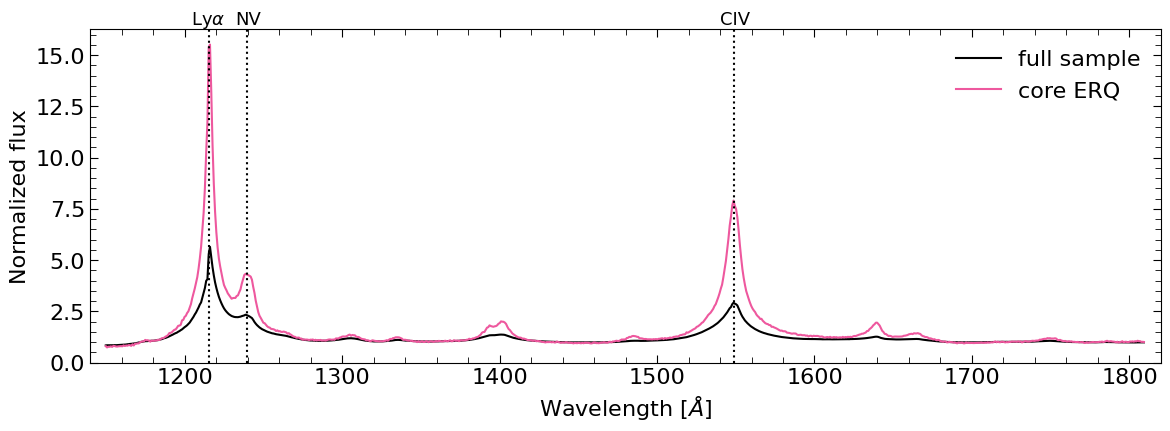

In [95]:
fig, ax = plt.subplots(figsize=(12,4.6))

plt.plot(median_full_1[:-1],median_full_0,color="black",label="full sample")
plt.plot(median_core_erq[1][:-1],median_core_erq[0],label="core ERQ",color=palette_dark[0])

ax.axvline(CIV_AIR,linestyle=":",color="black")
ax.text(1540,16.5,"CIV",fontsize=13)
ax.axvline(NV_AIR,linestyle=":",color="black")
ax.text(1232,16.5,"NV",fontsize=13)
ax.axvline(LYA_AIR,linestyle=":",color="black")
ax.text(1204,16.5,r"Ly$\alpha$",fontsize=13)

plt.legend(loc="upper right")

plt.xlim(1140,1820)

plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel("Normalized flux")

plt.tight_layout()

plt.savefig("images/median_flux_overall.png")

plt.plot()

### subset composite

In [36]:
color_bins = [2,3.5,3.9]

In [77]:
w3_detected = full.query("snr_w3>3")

set_1 = w3_detected.query("rew_civ>100")
set_2 = w3_detected.query("rew_civ<60")

In [78]:
np.random.seed(6)

n = 2000

# set_1_low_idx = np.random.choice(set_1[(set_1["z-w3"]>color_bins[0]) & (set_1["z-w3"]<color_bins[1])].index,n)
# set_1_med_idx = np.random.choice(set_1[(set_1["z-w3"]>color_bins[1]) & (set_1["z-w3"]<color_bins[2])].index,n)
# set_1_hig_idx = np.random.choice(set_1[(set_1["z-w3"]>color_bins[2])].index,n)

# set_2_low_idx = np.random.choice(set_2[(set_2["z-w3"]>color_bins[0]) & (set_2["z-w3"]<color_bins[1])].index,n)
# set_2_med_idx = np.random.choice(set_2[(set_2["z-w3"]>color_bins[1]) & (set_2["z-w3"]<color_bins[2])].index,n)
# set_2_hig_idx = np.random.choice(set_2[(set_2["z-w3"]>color_bins[2])].index,n)


set_1_low_idx = np.random.choice(set_1[(set_1["z-w3"]<3.4)].index,n)
set_1_hig_idx = np.random.choice(set_1[(set_1["z-w3"]>4.4)].index,n)

set_2_low_idx = np.random.choice(set_2[(set_2["z-w3"]<3.4)].index,n)
set_2_hig_idx = np.random.choice(set_2[(set_2["z-w3"]>4.4)].index,n)

In [55]:
def get_spectra(idx_list):
    lam_arr = []
    flux_arr = []

    for idx in idx_list:
        with h5py.File(SPECTRA_PATH, "r") as f:
            data = f[f"{idx}"][()]

            lam = data[0,:]
            flux = data[1,:]

            cont_params = ast.literal_eval(fit_params.loc[idx,"continuum_fit_lya_nv"])["fit_params"]

            cont_flux = _powerlaw(lam/1290,**cont_params)

            lam_arr.extend(lam)
            flux_arr.extend(flux/cont_flux)
    
    return lam_arr, flux_arr
    

In [79]:
set_1_hig_med = binned_statistic(*get_spectra(set_1_hig_idx),statistic="median",bins=(818))
# set_1_med_med = binned_statistic(*get_spectra(set_1_med_idx),statistic="median",bins=(818))
set_1_low_med = binned_statistic(*get_spectra(set_1_low_idx),statistic="median",bins=(818))

set_2_hig_med = binned_statistic(*get_spectra(set_2_hig_idx),statistic="median",bins=(818))
# set_2_med_med = binned_statistic(*get_spectra(set_2_med_idx),statistic="median",bins=(818))
set_2_low_med = binned_statistic(*get_spectra(set_2_low_idx),statistic="median",bins=(818))

/tmp/ipykernel_9773/1965150925.py:17: RuntimeWarning: divide by zero encountered in divide
  flux_arr.extend(flux/cont_flux)


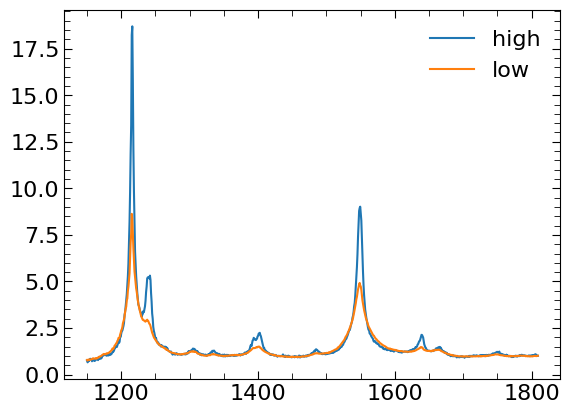

In [80]:
plt.plot(set_1_hig_med[1][:-1],set_1_hig_med[0],label="high")
# plt.plot(set_1_med_med[1][:-1],set_1_med_med[0],label="medium")
plt.plot(set_1_low_med[1][:-1],set_1_low_med[0],label="low")
plt.legend()

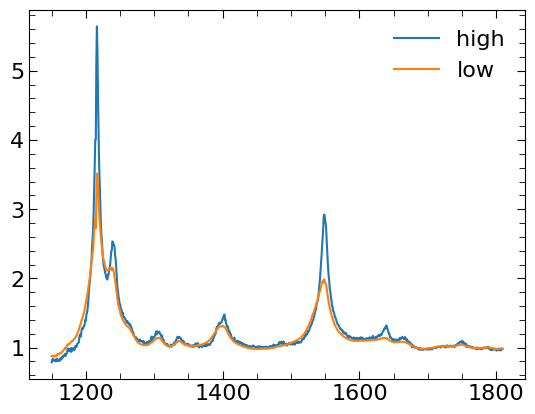

In [82]:
plt.plot(set_2_hig_med[1][:-1],set_2_hig_med[0],label="high")
# plt.plot(set_2_med_med[1][:-1],set_2_med_med[0],label="medium")
plt.plot(set_2_low_med[1][:-1],set_2_low_med[0],label="low")
plt.legend()